In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('bank.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [4]:
df_encoded=pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,30,1787,19,79,1,-1,0,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,33,4789,11,220,1,339,4,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,35,1350,16,185,1,330,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,199,4,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,59,0,5,226,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [5]:
X=df_encoded.drop("y_yes", axis=1)
Y=df_encoded["y_yes"]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

In [7]:
dummy=DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)

Y_dummy=dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(Y_test, Y_dummy))
print("Dummy Recall:", recall_score(Y_test, Y_dummy))

Dummy Accuracy: 0.8850574712643678
Dummy Recall: 0.0


In [8]:
tree=DecisionTreeClassifier(random_state=42)
tree.fit(X_train, Y_train)

Y_pred=tree.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 score:", f1_score(Y_test, Y_pred))

Accuracy: 0.8488063660477454
Precision: 0.3710691823899371
Recall: 0.45384615384615384
F1 score: 0.4083044982698962


In [9]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

       False       0.93      0.90      0.91      1001
        True       0.37      0.45      0.41       130

    accuracy                           0.85      1131
   macro avg       0.65      0.68      0.66      1131
weighted avg       0.86      0.85      0.86      1131



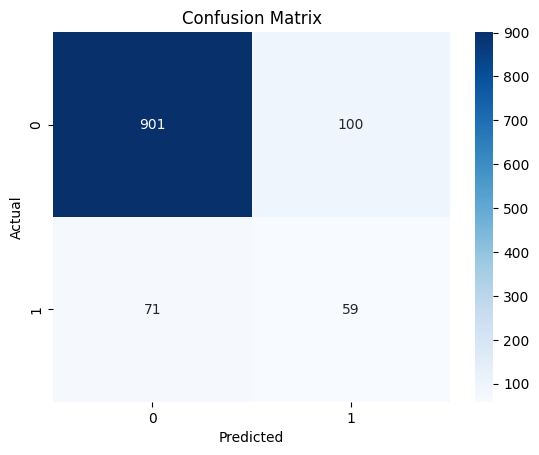

In [10]:
cm=confusion_matrix(Y_test, Y_pred)

plt.figure()
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
depths=range(1,21)
cv_scores=[]

for d in depths:
    model=DecisionTreeClassifier(
        max_depth=d,
        class_weight='balanced',
        random_state=42
    )

    scores=cross_val_score(model, X_train, Y_train, cv=5, scoring='recall')
    cv_scores.append(scores.mean())

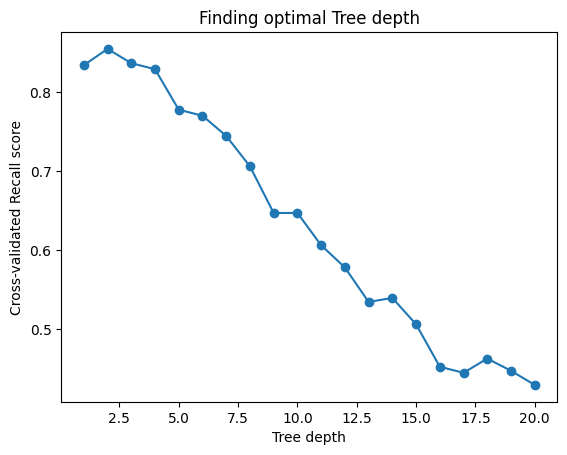

Best Depth: 2


In [12]:
plt.figure()
plt.plot(depths, cv_scores, marker='o')
plt.xlabel('Tree depth')
plt.ylabel('Cross-validated Recall score')
plt.title('Finding optimal Tree depth')
plt.show()

best_depth= depths[np.argmax(cv_scores)]
print("Best Depth:", best_depth)

In [13]:
best_tree = DecisionTreeClassifier(
    max_depth = best_depth,
    class_weight = "balanced",
    random_state = 42
)
best_tree.fit(X_train, Y_train)

# Generate predictions
Y_train_pred = best_tree.predict(X_train)
Y_test_pred = best_tree.predict(X_test)

print("Train Accuracy:", best_tree.score(X_train, Y_train))
print("Test Accuracy:", best_tree.score(X_test, Y_test))

# recall (positive class = 1)
print("Train Recall:", recall_score(Y_train, Y_train_pred))
print("Test Recall:", recall_score(Y_test, Y_test_pred))

print("Train Precision:", precision_score(Y_train,Y_train_pred))
print("Test Precision:", precision_score(Y_test,Y_test_pred))

Train Accuracy: 0.647787610619469
Test Accuracy: 0.636604774535809
Train Recall: 0.8925831202046036
Test Recall: 0.8846153846153846
Train Precision: 0.23251165889407063
Test Precision: 0.22504892367906065


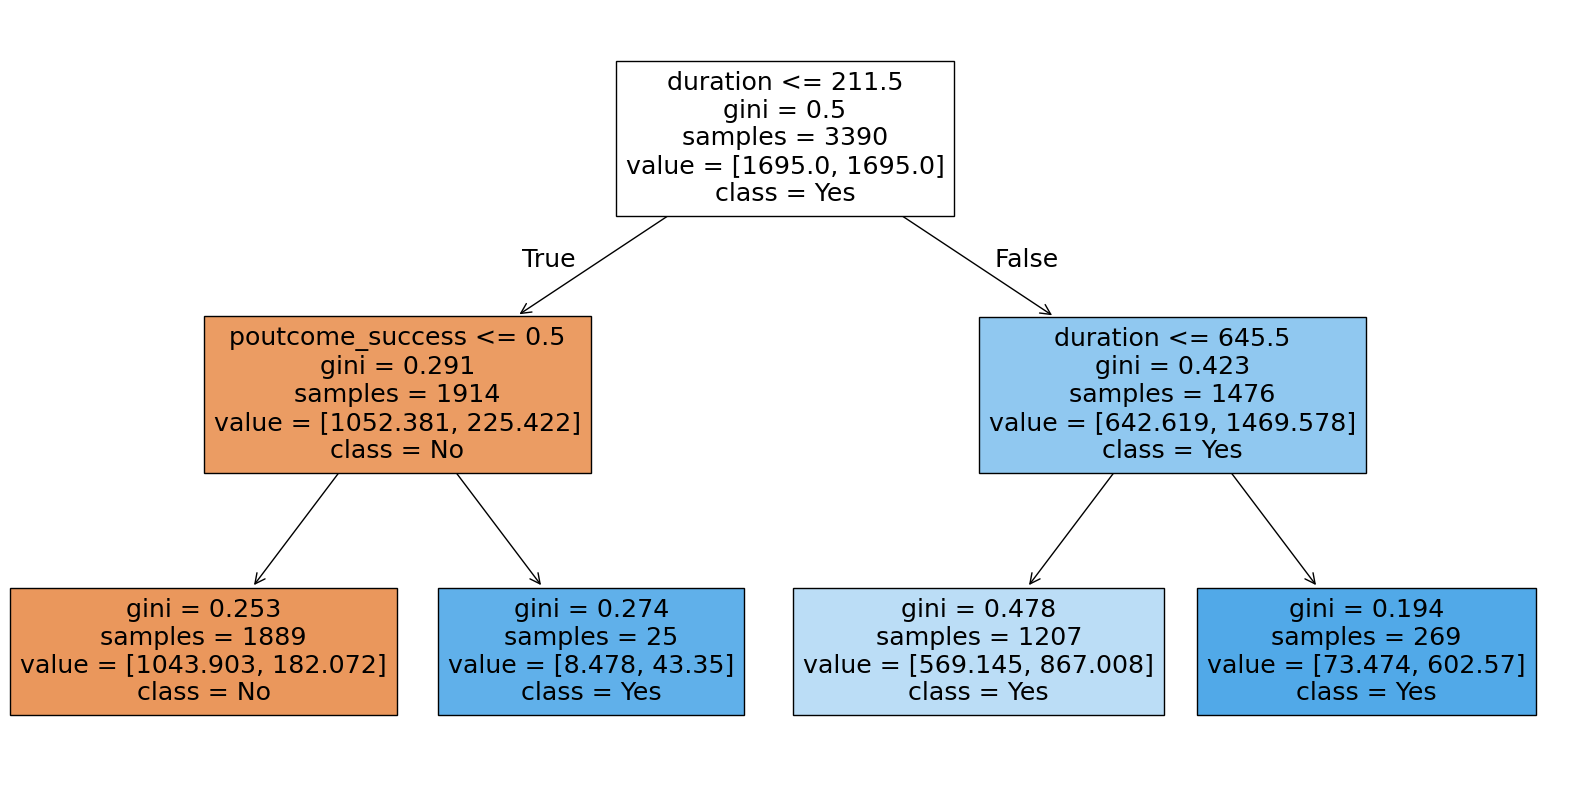

In [14]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_tree,
    max_depth=3,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

In [15]:
Y_proba=best_tree.predict_proba(X_test)[:,1]

In [16]:
precision, recall, thresholds= precision_recall_curve(Y_test, Y_proba)

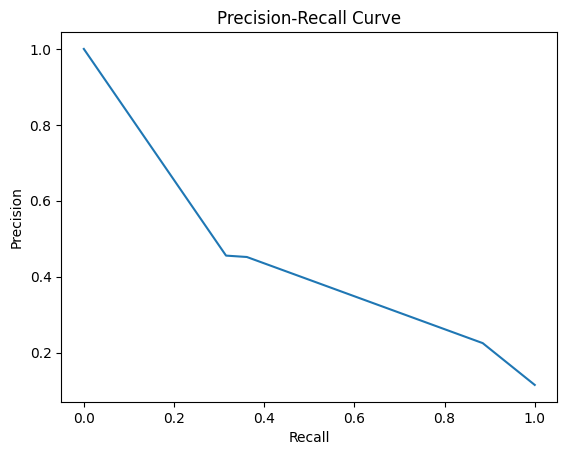

In [17]:
plt.figure()
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()